In [1]:
import fastbook
fastbook.setup_book()

In [2]:
from fastbook import *

In [3]:
from fastai.vision.all import *
path = untar_data(URLs.PASCAL_2007)

<div><progress max="1637796771" value="1637801984"></progress> 100.00% [1637801984/1637796771 03:17&lt;00:00]</div>

In [4]:
df =pd.read_csv(path/'train.csv')
df.head()

,fname,labels,is_valid
0,000005.jpg,chair,True
1,000007.jpg,car,True
2,000009.jpg,horse person,True
3,000012.jpg,car,False
4,000016.jpg,bicycle,True


In [22]:
def get_x(r): return path/'train'/r['fname']
def get_y(r): return r['labels'].split(' ')
dblock = DataBlock(get_x = get_x, get_y = get_y)
dsets = dblock.datasets(df)
dsets.train[0]

(Path('/home/z004psfe/.fastai/data/pascal_2007/train/007011.jpg'), ['dog'])

In [23]:
def splitter(df):
    train = df.index[~df['is_valid']].tolist()
    valid = df.index[df['is_valid']].tolist()
    return train,valid

dblock = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                   splitter=splitter,
                   get_x=get_x, 
                   get_y=get_y)

dsets = dblock.datasets(df)
dsets.train[0]

(PILImage mode=RGB size=500x333,
 TensorMultiCategory([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [32]:
dblock = DataBlock(blocks=(ImageBlock, MultiCategoryBlock),
                   splitter=splitter,
                   get_x=get_x, 
                   get_y=get_y,
                   item_tfms = RandomResizedCrop(128, min_scale=0.35))
dls = dblock.dataloaders(df,num_workers=0)

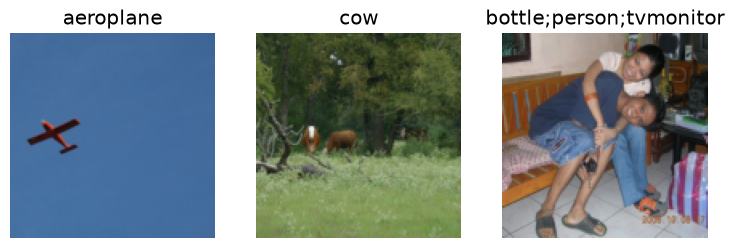

In [33]:
dls.show_batch(nrows=1, ncols=3)

In [34]:
learn = vision_learner(dls, resnet18)


In [35]:
x,y = to_cpu(dls.train.one_batch())
activs = learn.model(x)
activs.shape

torch.Size([64, 20])

In [36]:
activs[19]

TensorImage([-2.7029, -0.7815,  0.0700, -0.6164, -2.3496, -2.5339, -4.2413, -1.8345, -1.0747,  0.9545,  4.5143, -0.9016,  0.8475,  0.3218, -0.4481,  1.8642,  1.1090,  1.4295,  0.8776,  0.0264],
            grad_fn=<AliasBackward0>)

In [37]:
def binary_cross_entropy(inputs, targets):
    inputs = inputs.sigmoid()
    return -torch.where(targets==1, inputs, 1-inputs).log().mean()

In [39]:
learn = vision_learner(dls, resnet50, metrics=partial(accuracy_multi, thresh=0.2))
learn.fine_tune(3, base_lr=3e-3, freeze_epochs=4)

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.950036,0.717771,0.222490,00:40
1,0.827528,0.547888,0.283785,00:38
2,0.601495,0.193470,0.833426,00:38
3,0.356822,0.116957,0.944283,00:38


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.128187,0.104451,0.949701,00:39
1,0.111409,0.097529,0.955817,00:38
2,0.097727,0.094132,0.955916,00:38


In [40]:
preds,targs = learn.get_preds()

In [41]:
accuracy_multi(preds, targs, thresh=0.9, sigmoid=False)

TensorBase(0.9595)

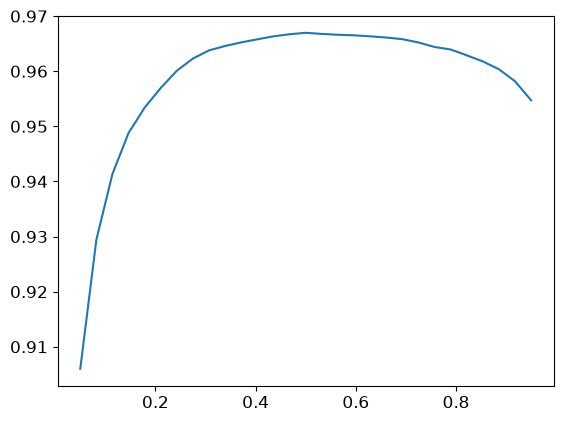

In [42]:
xs = torch.linspace(0.05,0.95,29)
accs = [accuracy_multi(preds, targs, thresh=i, sigmoid=False) for i in xs]
plt.plot(xs,accs);